In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sb_bond_functions as ba
import MDAnalysis as mda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from statsmodels.stats.diagnostic import lilliefors

In [9]:
reference_struc = 'centered_active.gro' 
trajectory = ['test.xtc'] 

In [10]:
all_pairs, current_pairs, combined_coords, n_mainchain_residues, pvalue_df = ba.compute_com_contacts(trajectory, reference_struc, 
                        batch_size=100, stride=1, 
                        mc_contact_threshold=8.0, sc_contact_threshold=8.0, 
                        mc_sc_contact_threshold=8.0, variance_percentile=75, pvalue_threshold=None,
                        n_jobs=1)

/home/romiromi/work/bond_analysis/bondflow/venv/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
test.xtc: 100%|██████████| 251/251 [00:00<00:00, 368.57it/s]


Mainchain-Mainchain pairs: 544446
Sidechain-Sidechain pairs: 544446
Mainchain-Sidechain pairs: 1089936


Stage 1: Contact Filter: 100%|██████████| 5445/5445 [00:05<00:00, 978.36it/s] 


MC-MC pairs after contact filter: 7,381


Stage 1: Contact Filter:   0%|          | 0/5445 [00:00<?, ?it/s]/home/romiromi/work/bond_analysis/bondflow/salt_bridge_analysis/sb_bond_functions.py:173: RuntimeWarning: All-NaN slice encountered
  min_distances = np.nanmin(batch_distances, axis=0)
Stage 1: Contact Filter: 100%|██████████| 5445/5445 [00:05<00:00, 960.06it/s] 


...

MC-SC pairs after contact filter: 9,735
Total pairs after Stage 1 (all classes): 21,041


Stage 2: Calculating Variances: 100%|██████████| 211/211 [00:00<00:00, 766.82it/s]


Pairs after variance filter: 5,261


Stage 3: Calculating Distributions: 100%|██████████| 53/53 [00:01<00:00, 26.67it/s]


Pairs after distribution filter: 5,261


In [11]:
# Create a distance dataframe to look at salt bridge distances 
# and their variance across the trajectory
model = mda.Universe(reference_struc, trajectory)
protein_residues = model.select_atoms("protein").residues
df = ba.compute_residue_pair_distances(combined_coords, current_pairs, n_mainchain_residues, protein_residues)
print(df.head())

                       pair_name bond_type  idx_i  idx_j   frame_0   frame_1  \
0    CYS55_653(MC)_SER31_629(SC)     MC-SC    653   1673  8.911698  9.747415   
1  LEU183_781(MC)_SER222_820(SC)     MC-SC    781   1864  8.482677  8.419325   
2    GLY54_652(MC)_CYS55_653(SC)     MC-SC    652   1697  5.330527  5.332018   
3  LEU183_781(MC)_PRO196_794(SC)     MC-SC    781   1838  5.544250  5.857393   
4  LEU183_781(MC)_THR195_793(SC)     MC-SC    781   1837  5.243628  4.607110   

     frame_2   frame_3   frame_4   frame_5  ...  frame_243  frame_244  \
0  10.534528  8.787740  8.110927  7.962986  ...  11.360309  10.677562   
1   7.744010  8.358642  8.246510  8.341942  ...  11.798461  12.147272   
2   5.399248  5.333582  5.302859  5.262588  ...   4.528484   4.386331   
3   5.196932  5.433079  5.707460  5.781364  ...   7.509737   8.059969   
4   4.297764  4.283587  4.413064  4.722801  ...   6.655680   7.298258   

   frame_245  frame_246  frame_247  frame_248  frame_249  frame_250  \
0  11.463

In [12]:
# Removes duplicates based on resname and resnum!!!
unique_pairs = ba.remove_duplicate_pairs(current_pairs, protein_residues, n_mainchain_residues) 
print(f"Original pairs: {len(current_pairs)}")
print(f"Unique pairs:   {len(unique_pairs)}")

Original pairs: 5261
Unique pairs:   3321


In [13]:
# Search for salt bridges in the current pairs
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map_filtered(reference_struc, trajectory, current_pairs, distance_threshold=5.0)
print(binary_contact_map.shape)

print(distance_map.shape)

(115, 251)
(115, 251)


In [14]:
# Create sorted distance dataframe to look at salt bridge distances 
# and their variance across the trajectory/trajectories
dist_df, sb_names, std_df = ba.create_sorted_distance_dataframe(contact_map_names, binary_contact_map, distance_map)

In [15]:
print(dist_df.head())

Salt bridge  GLU48_LYS51  ASP269_ARG271  LYS378_GLU407  ASP73_LYS75  \
0               3.985601       4.245869       3.876313     8.935426   
1               3.941506       4.130144       5.280495     7.345657   
2               6.269331       3.856976       3.687565     9.013930   
3               6.378443       5.322020       5.178752     9.721452   
4               5.129006       4.778552       3.331952     9.062594   

Salt bridge  LYS174_GLU246  LYS114_GLU403  LYS13_GLU17  ARG540_GLU541  \
0                 3.892861       5.801428     4.346198       4.076227   
1                 5.803315       5.688401     4.018025       4.184574   
2                 9.835293       7.270126     3.933160       3.960264   
3                 8.788840       7.548992     4.500556       4.355675   
4                 7.752556       7.659425     6.608699       4.141754   

Salt bridge  GLU390_ARG393  LYS87_ASP90  ...  ARG117_GLU119  LYS136_GLU140  \
0                 5.968794     3.906238  ...       4.601

/home/romiromi/work/bond_analysis/bondflow/venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=self.figsize)


<Axes: >

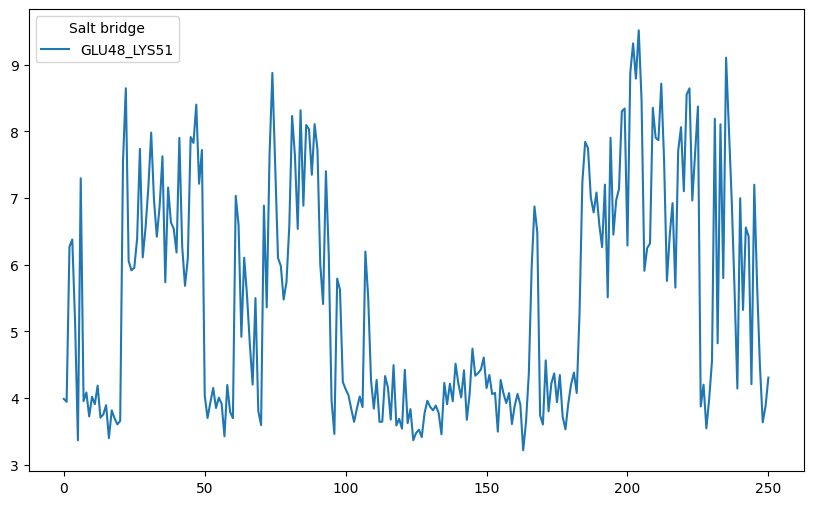

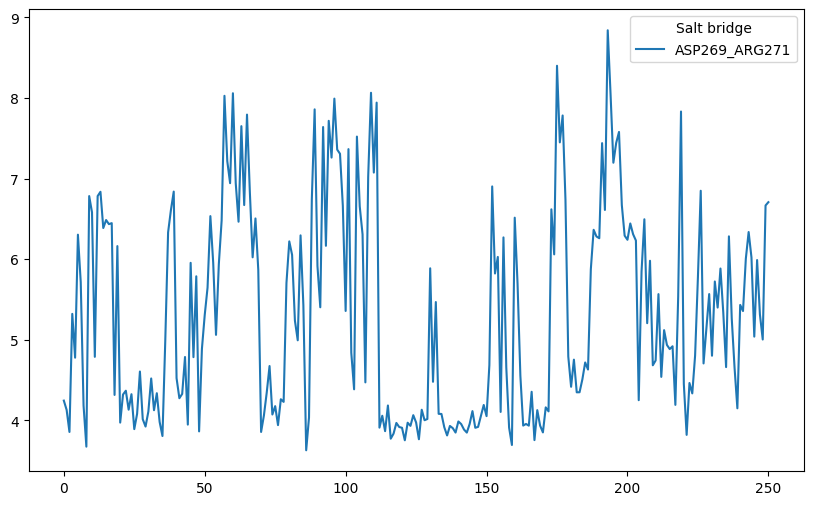

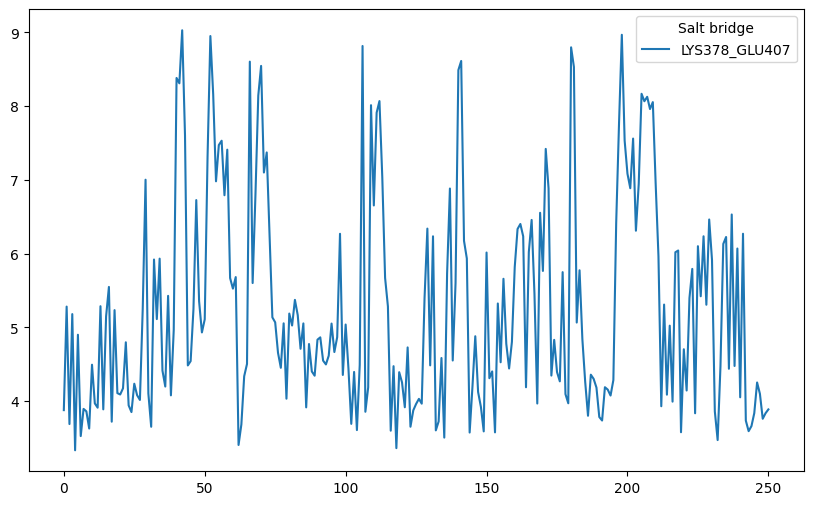

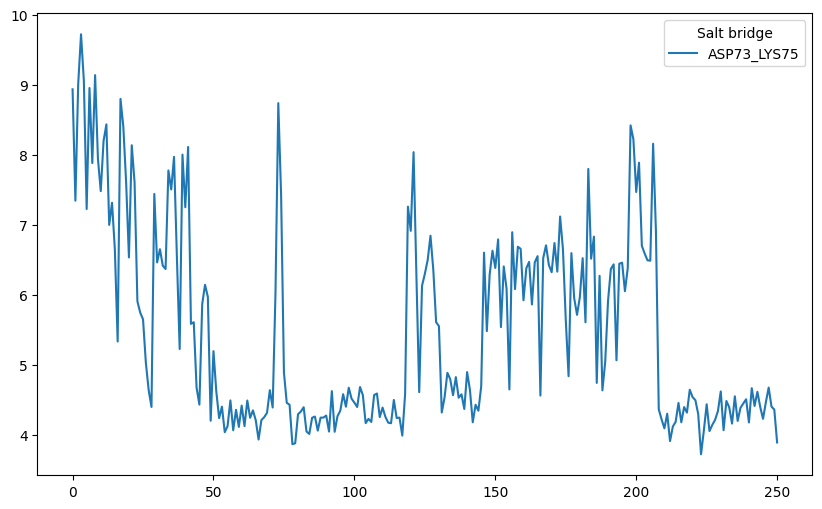

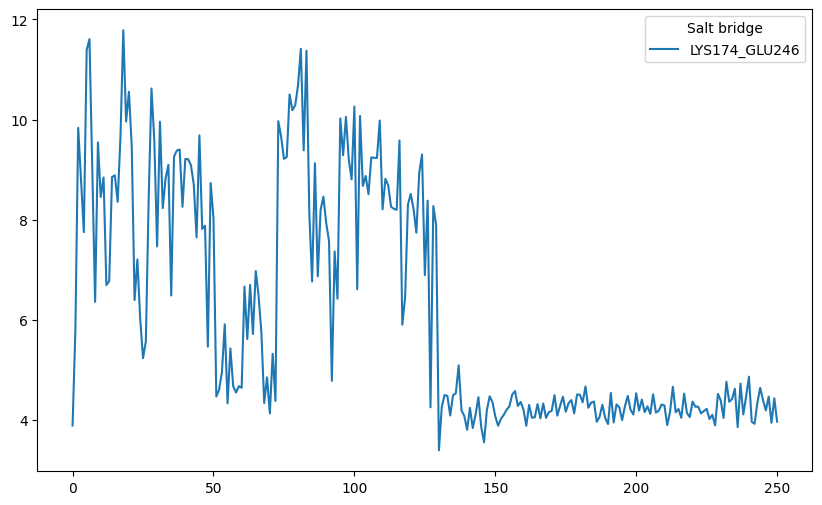

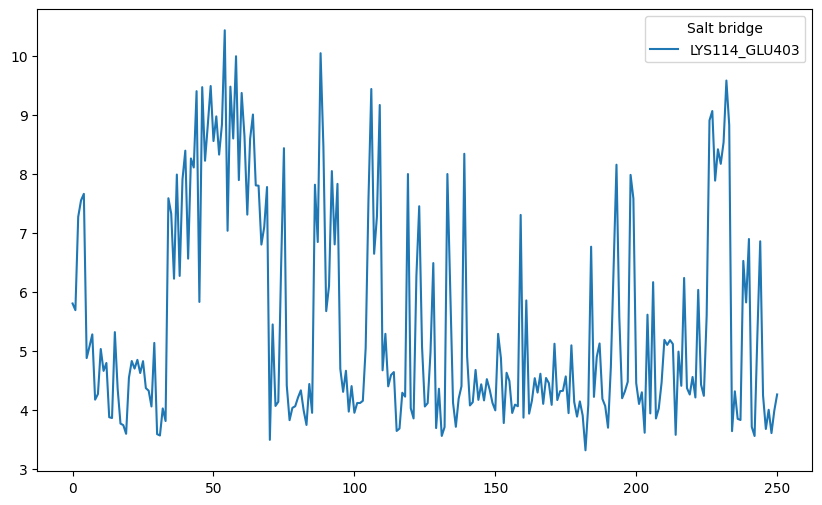

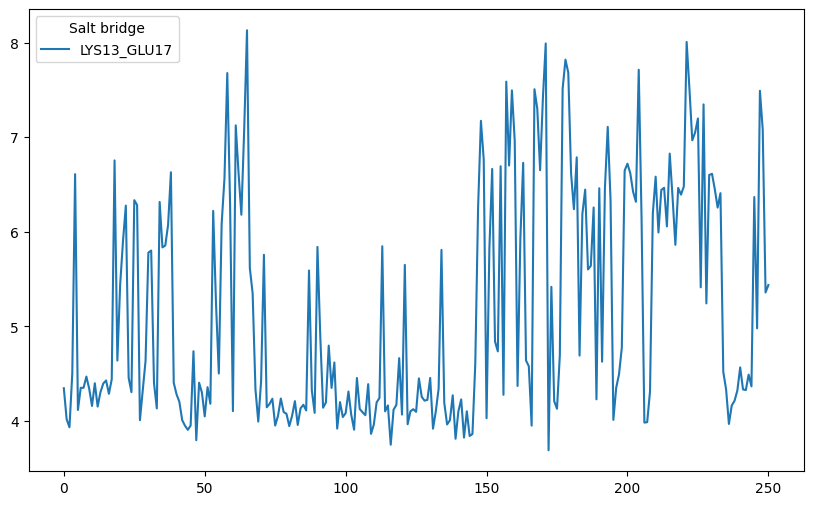

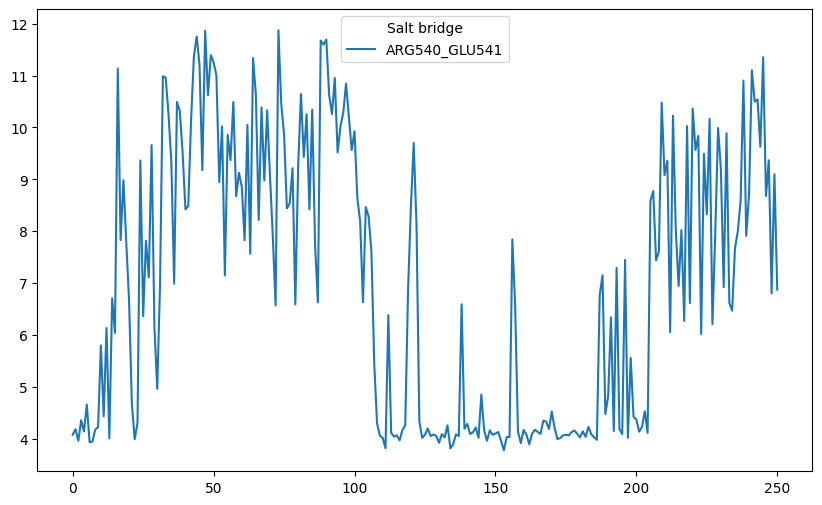

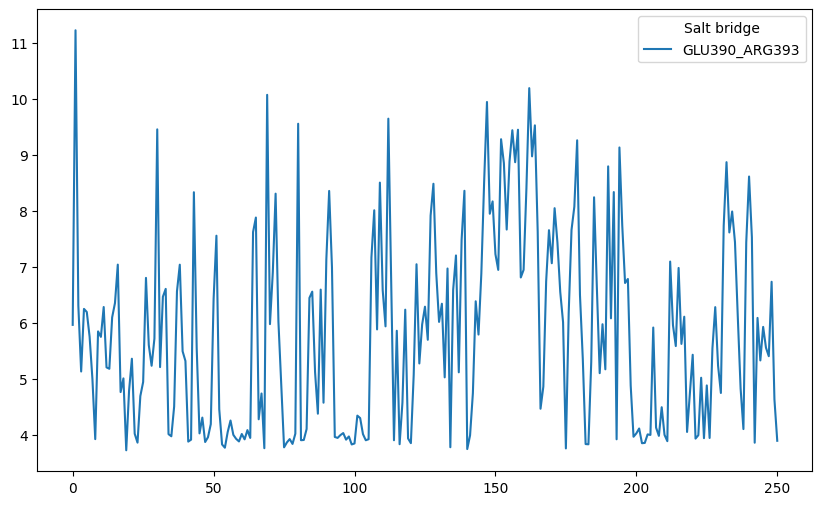

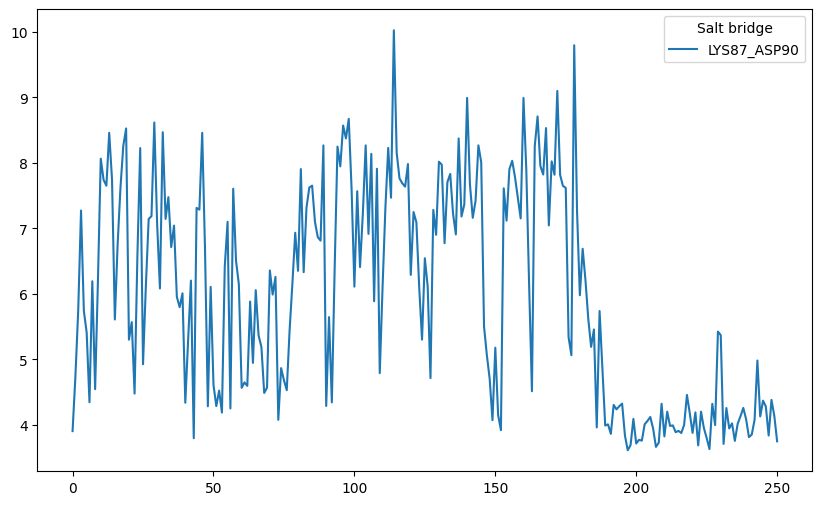

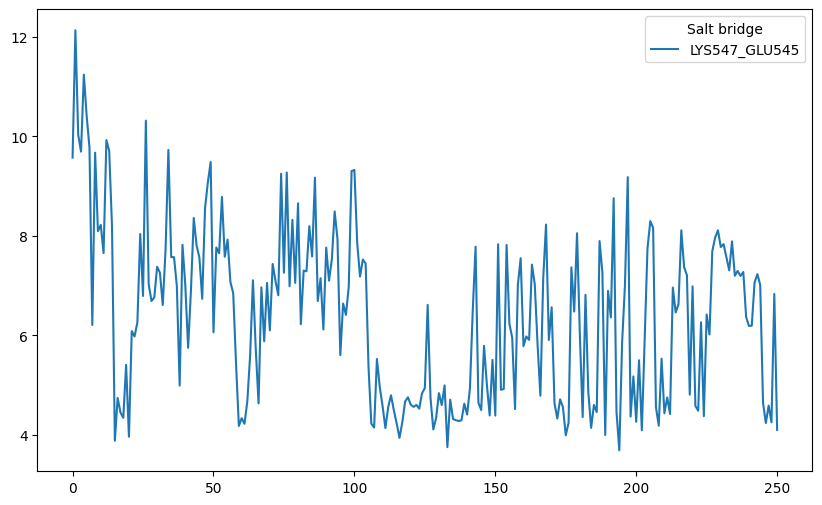

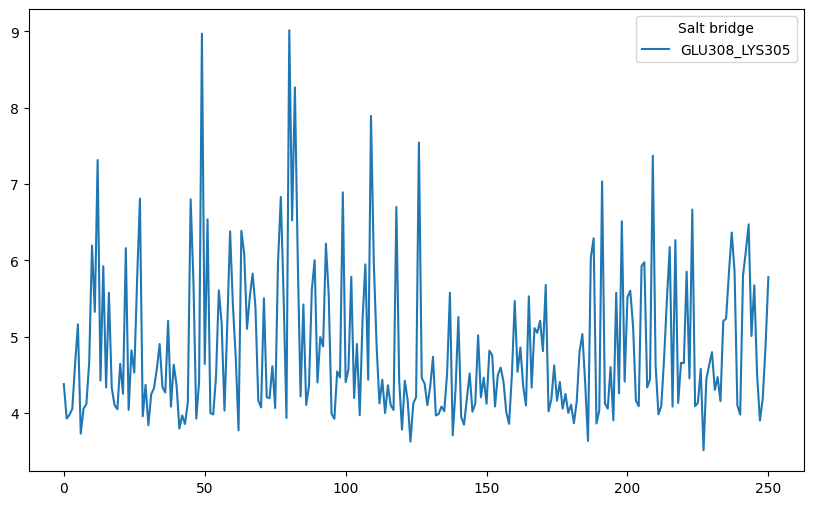

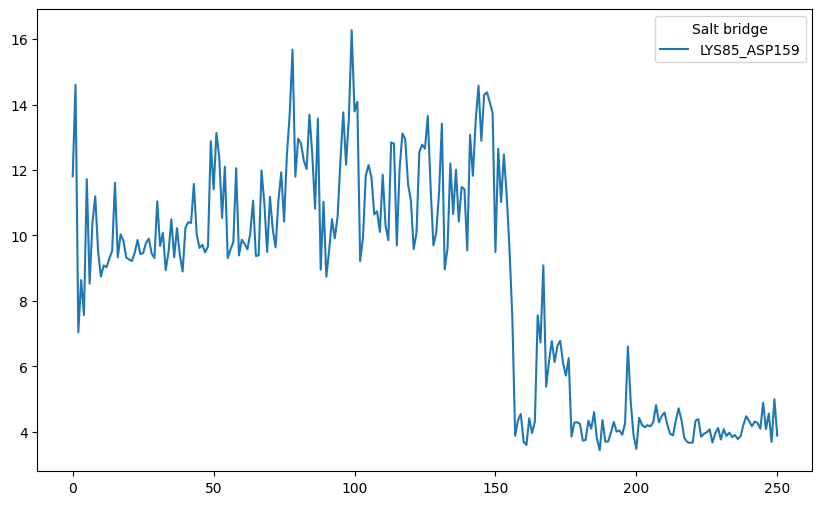

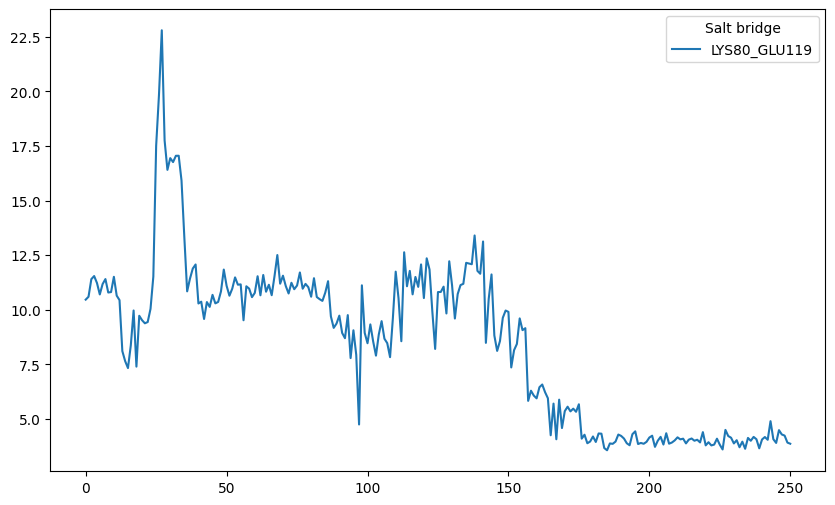

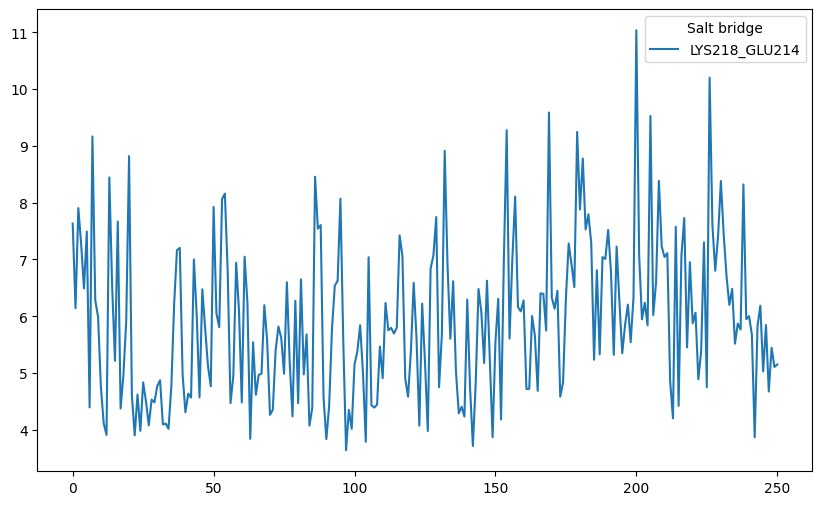

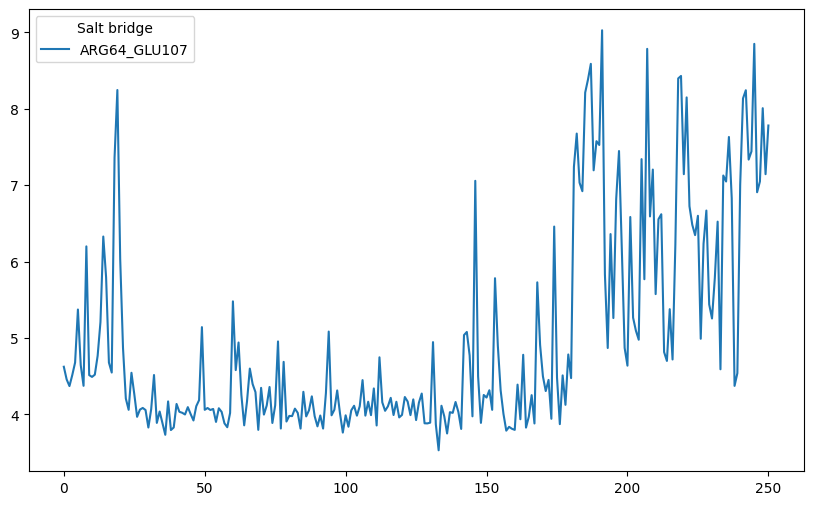

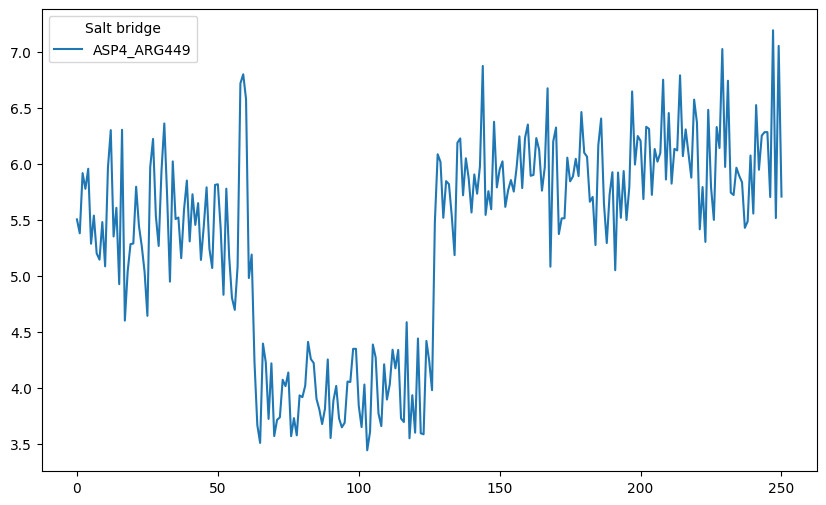

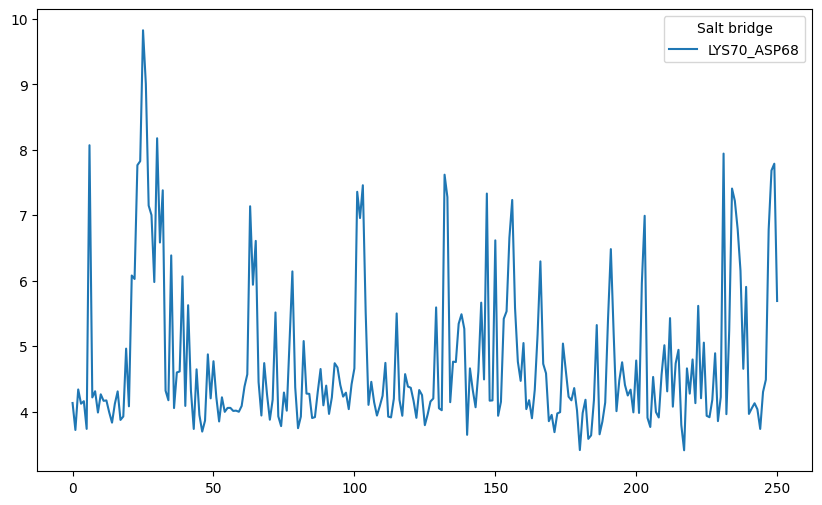

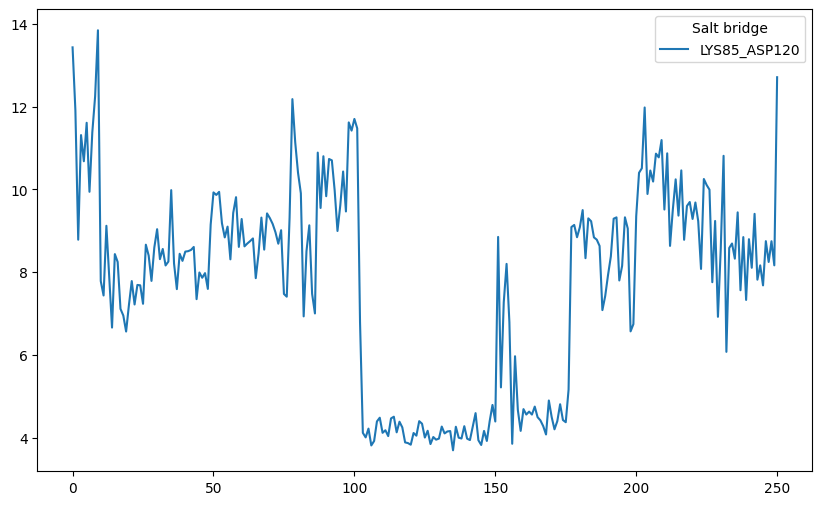

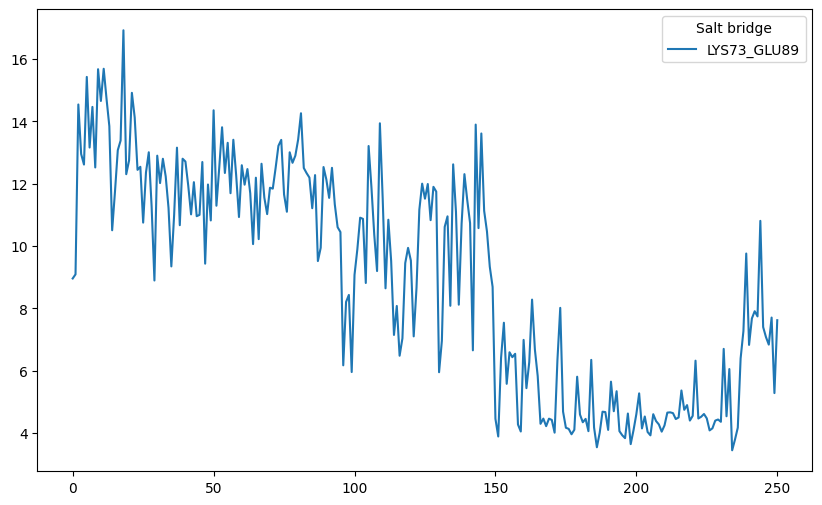

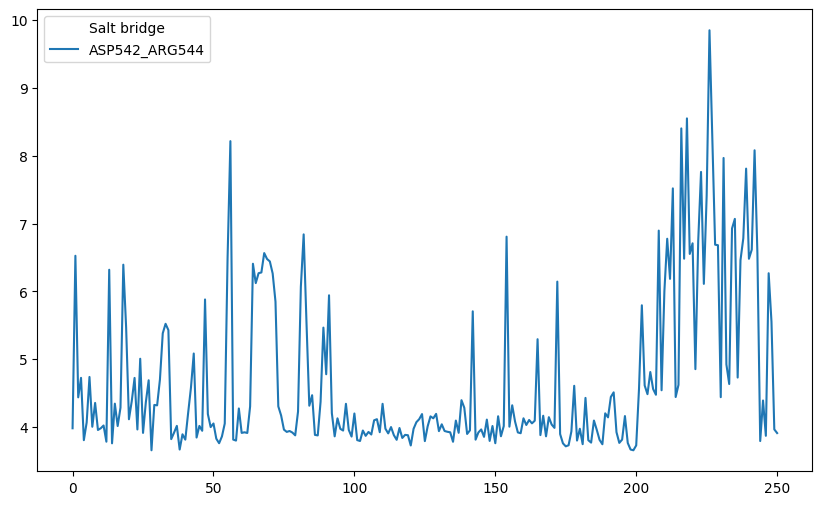

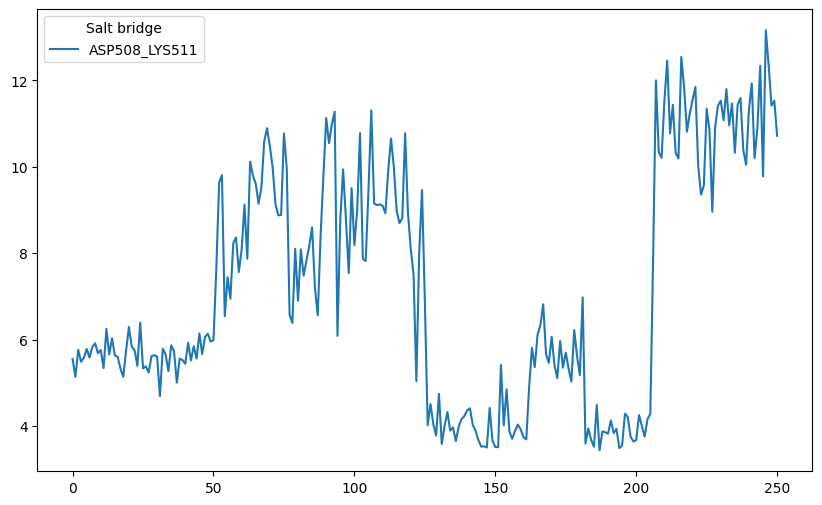

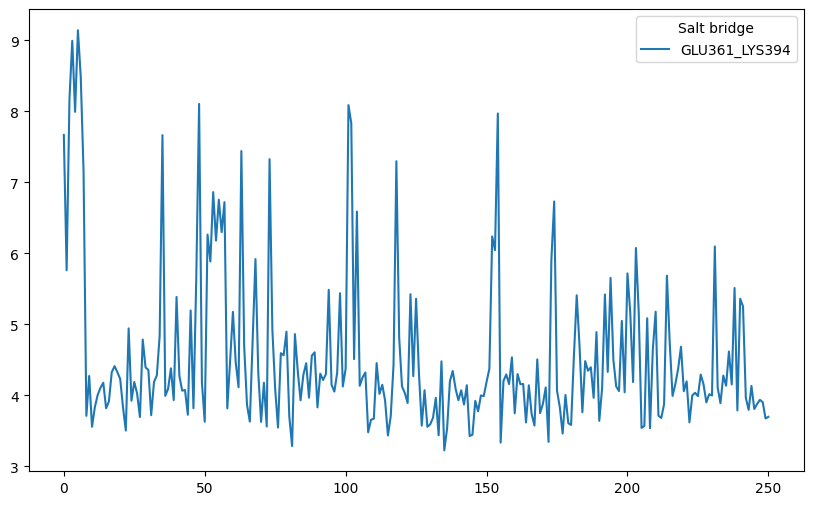

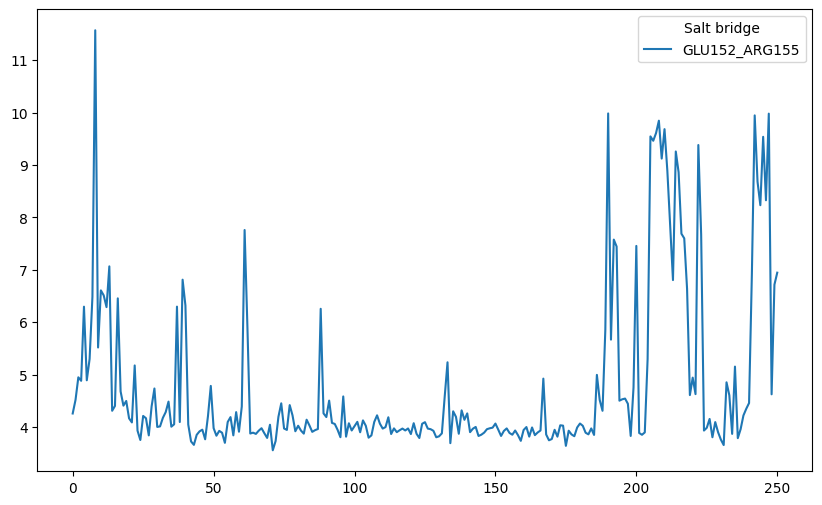

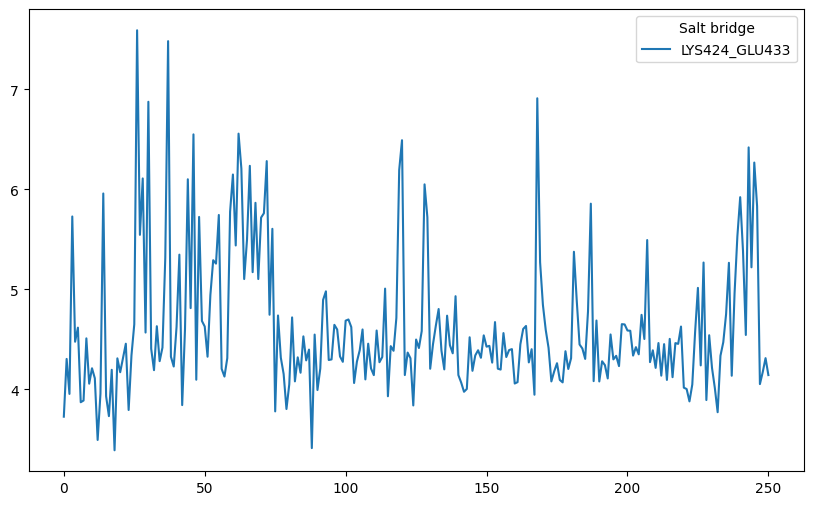

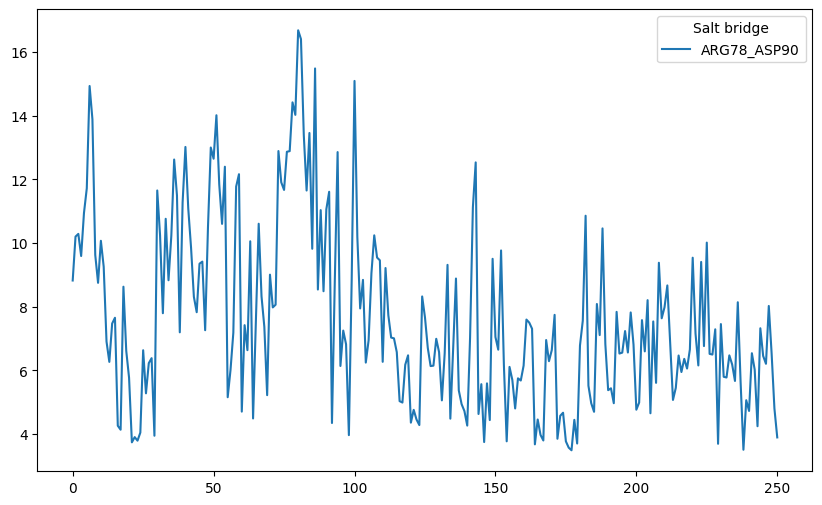

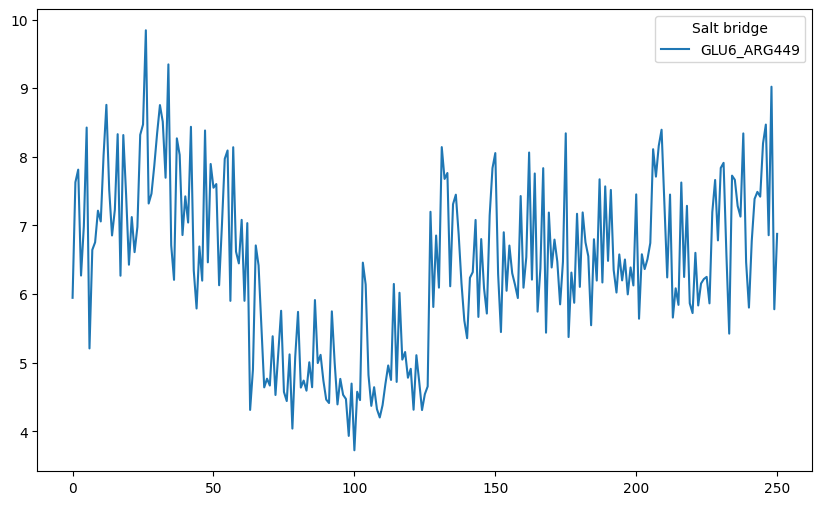

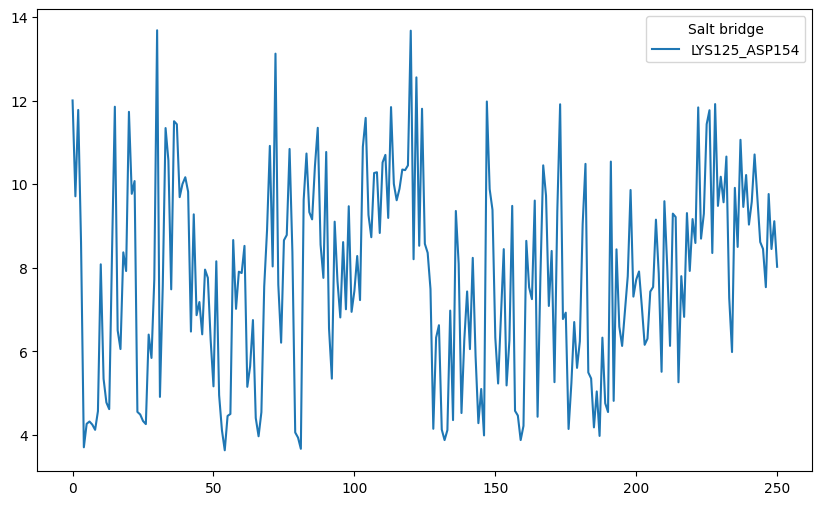

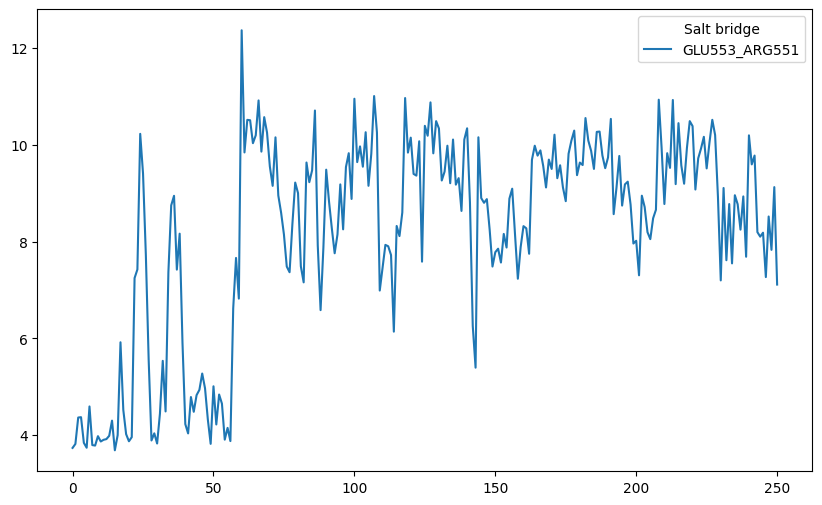

In [16]:
df2 = dist_df
sb_names = sb_names

df2.plot.line(y=[f'{sb_names[0]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[1]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[2]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[3]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[4]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[5]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[6]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[7]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[8]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[9]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[10]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[11]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[12]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[13]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[14]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[15]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[16]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[17]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[18]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[19]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[20]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[21]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[22]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[23]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[24]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[25]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[26]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[27]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[28]}'],  figsize=(10,6))